# Trends and Decomposition

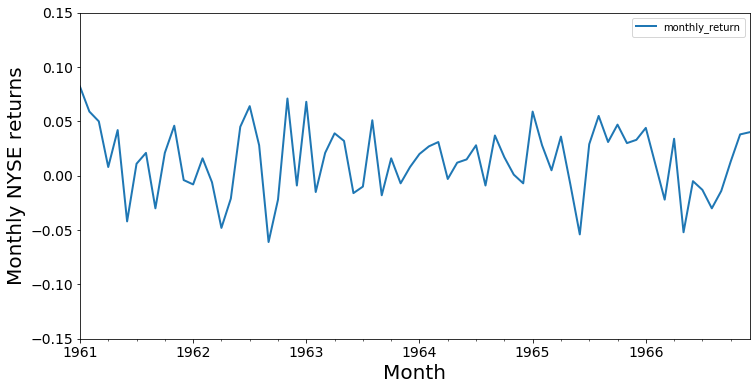

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

data = pd.read_csv('data/types_of_trends/NYSE_monthly.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
data.plot(figsize=(12,6), linewidth=2, fontsize=14)
plt.xlabel('Month', fontsize=20)
plt.ylabel('Monthly NYSE returns', fontsize=20)
plt.ylim((-0.15, 0.15));

In [ ]:
data.head()

,monthly_return
Month,
1961-01-01,0.082
1961-02-01,0.059
1961-03-01,0.050
1961-04-01,0.008
1961-05-01,0.042


### Linear trend

#### Upward linear

In many cases, there will be some sort of trend, however. A common trend type is a linear trend, where the observation grows bigger over time, or declines. Below is the plot of quarterly U.K. imports of goods and services over time.

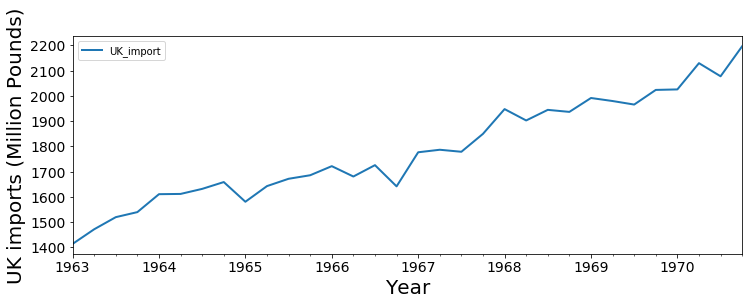

In [ ]:
data = pd.read_csv('data/types_of_trends/uk_imports.csv')
data['Quarter'] = pd.to_datetime(data['Quarter'])
data.set_index('Quarter', inplace=True)

data.plot(figsize=(12,4), linewidth=2, fontsize=14)
plt.ylabel('UK imports (Million Pounds)', fontsize=20)
plt.xlabel('Year', fontsize=20);

#### Downward linear

Below is a record of the winning times for the men's 400 m final at the Olympics. Note how the winning time has gone down over the years from 1896 to 1996.

In [ ]:
data = pd.read_csv('data/types_of_trends/winning_400m.csv')
data['year'] = pd.to_datetime(data['year'].astype(str))

data.set_index('year', inplace=True)

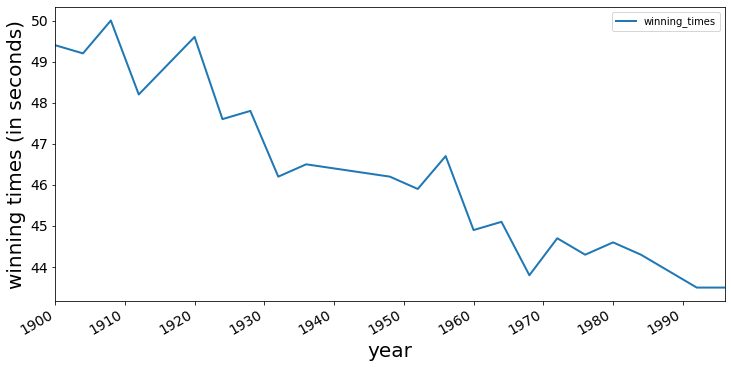

In [ ]:
data.plot(figsize=(12,6), linewidth=2, fontsize=14)
plt.xlabel('year', fontsize=20)
plt.ylabel("winning times (in seconds)", fontsize=20);

### Exponential trend

Another type of trend that can be observed is an exponential trend. A typical example could be a company's sales. Initially, when small companies start to grow, there sales could be slower; but when their product catches people's attention, the sales can start to grow exponentially. A simulated example can be found below.

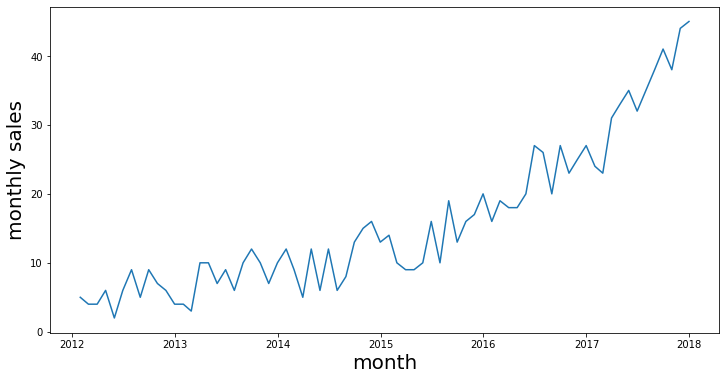

In [ ]:
# generated data 
years = pd.date_range('2012-01', periods=72, freq='M')
index = pd.DatetimeIndex(years)

np.random.seed(3456)
sales = np.random.randint(-4, high=4, size=72)
bigger = np.array([0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,
                   3,3,3,3,3,3,3,3,7,7,7,7,7,7,7,7,7,7,7,
                   11,11,11,11,11,11,11,11,11,11,18,18,18,
                   18,18,18,18,18,18,26,26,26,26,26,36,36,36,36,36])
data = pd.Series(sales+bigger+6, index=index)
ts = data
fig = plt.figure(figsize=(12,6))
plt.plot(data)
plt.xlabel('month', fontsize=20)
plt.ylabel('monthly sales', fontsize=20)
plt.show()

### Periodic Trend

Trends can also go both up and down. In many applications, what will happen is that trends are periodic. Think about temperature trends: while temperature will go up in summer, it will go down again in winter, and we can expect to see a cyclical pattern. The Australian minimum temperature dataset shows the result below.

In [ ]:
data = pd.read_csv('data/types_of_trends/min_temp.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

data.head()

,Daily_min
Date,
1981-01-01,20.7
1981-02-01,17.9
1981-03-01,18.8
1981-04-01,14.6
1981-05-01,15.8


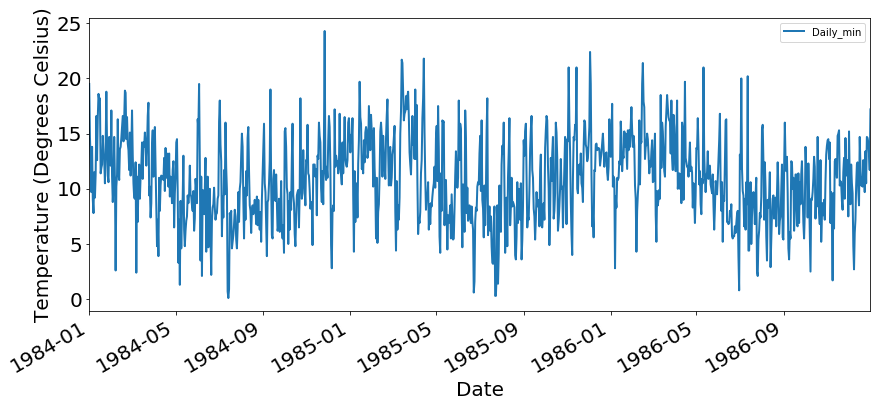

In [ ]:
data_slice= data['1984':'1986']
data_slice.plot(figsize=(14,6), linewidth=2, fontsize=20)
plt.xlabel('Date', fontsize=20)
plt.ylabel('Temperature (Degrees Celsius)', fontsize=20);

### Trend with an increasing variance

In the previous trend types, the variability remained constant over time. But in some cases, this might not be the case, and variability can change over time. A simulated example is shown in the plot below.

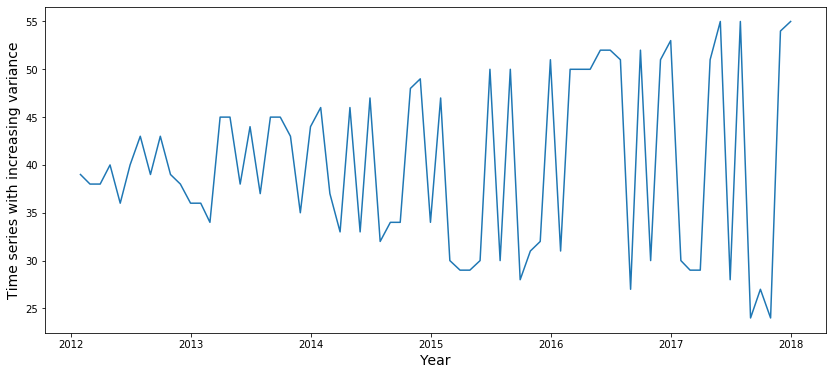

In [ ]:
# Generated data 
years = pd.date_range('2012-01', periods=72, freq='M')
index = pd.DatetimeIndex(years)

np.random.seed(3456)
sales= np.random.randint(-4, high=4, size=72)

add = np.where(sales>0, 1, -1)
bigger = np.array([0,0,0,0,0,0,0,0,0,1,1,1,1,2,2,2,2,2,2,2,2,2,3,3,
                   3,3,3,3,4,4,5,5,6,6,6,6,6,7,7,7,7,7,7,8,8,8,8,8,8,8,
                   9,9,9,9,9,9,9,9,10,10,10,10,10,10,12,12,12,12,12,12,12,12])
data = pd.Series((sales+add*bigger)+40, index=index)

fig = plt.figure(figsize=(14,6))
plt.plot(data)
plt.ylabel('Time series with increasing variance', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.show()

### Periodic and upward trend

This plane passenger data between July '62 and May '72 shows that a time series can have a periodic (seasonal) trend in conjunction with an upward trend over time.

In [ ]:
air = pd.read_csv('data/types_of_trends/airpassengers.csv')
air['Month'] = pd.to_datetime(air['Month'])
air.set_index('Month', inplace=True)
air.head()

,pass_miles_dom
Month,
1962-07-01,101.6
1962-08-01,101.5
1962-09-01,84.3
1962-10-01,51.0
1962-11-01,38.5


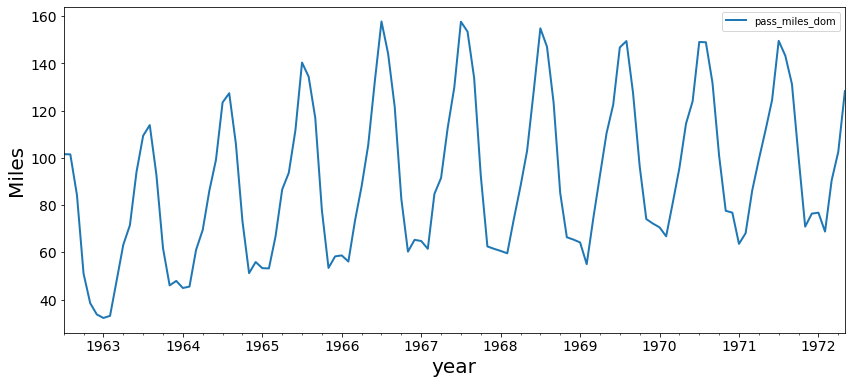

In [ ]:
air.plot(figsize=(14,6), linewidth=2, fontsize=14)
plt.xlabel('year', fontsize=20)
plt.ylabel('Miles', fontsize=20);

## Testing for trends

Let's look at our generated monthly sales data again with an exponential trend. From simply plotting the data, it is already pretty clear that there is a certain trend.

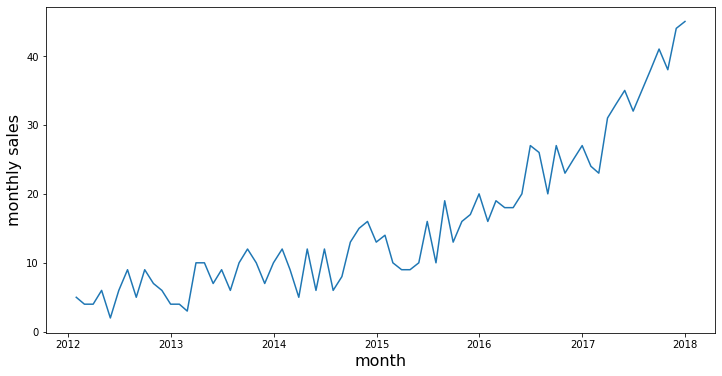

In [ ]:
# generated data 
years = pd.date_range('2012-01', periods=72, freq='M')
index = pd.DatetimeIndex(years)

np.random.seed(3456)
sales= np.random.randint(-4, high=4, size=72)
bigger = np.array([0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,
                   3,3,3,3,3,3,3,3,7,7,7,7,7,7,7,7,7,7,7,
                   11,11,11,11,11,11,11,11,11,11,18,18,18,
                   18,18,18,18,18,18,26,26,26,26,26,36,36,36,36,36])
data = pd.Series(sales+bigger+6, index=index)
ts = data
fig = plt.figure(figsize=(12,6))
plt.plot(data)
plt.xlabel('month', fontsize=16)
plt.ylabel('monthly sales', fontsize=16)
plt.show()

In what follows, we'll discuss two formal ways to assess trends:
- Rolling statistics
- The Dickey-Fuller Test

### Rolling statistics

We can plot the moving average or moving variance and see if it varies with time. By moving average/variance we mean **at any point in time $t$, we can take the average/variance of the $m$ last time periods. $m$ is then known as the window size**. 

Pandas has a built-in method called [rolling()](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.rolling.html), which can be called along with `.mean()` and `.std()` to calculate these rolling statistics. Let's take a window size of 8 for this example.

In [ ]:
roll_mean = ts.rolling(window=8, center=False).mean()
roll_std = ts.rolling(window=8, center=False).std()

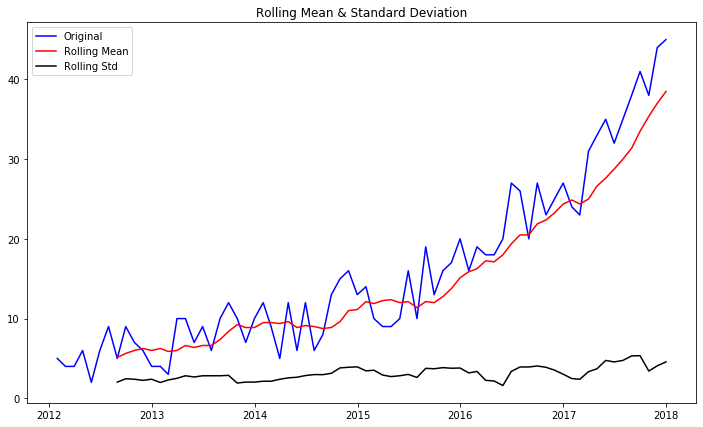

In [ ]:
fig = plt.figure(figsize=(12,7))
plt.plot(ts, color='blue', label='Original')
plt.plot(roll_mean, color='red', label='Rolling Mean')
plt.plot(roll_std, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

The red and black lines represent the rolling mean and rolling standard deviations. You can see that the mean is not constant over time, so we can reconfirm our conclusion that the time series is not stationary based on rolling mean and rolling standard error. 

### The Dickey-Fuller Test

The Dickey-Fuller test is a statistical test for testing stationarity. The null-hypothesis for the test is that the time series is not stationary. So if the test statistic is less than the critical value, we reject the null
hypothesis and say that the series is stationary. The Dickey-Fuller test is available in `tsa.stattools` sub-module of the `statsmodels` library. More details on this can be viewed [here](http://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html).

In [ ]:
from statsmodels.tsa.stattools import adfuller

dftest = adfuller(ts)

# Extract and display test results in a user friendly manner
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dftest)

(3.761375741674094, 1.0, 8, 63, {'1%': -3.5386953618719676, '5%': -2.9086446751210775, '10%': -2.591896782564878}, 314.84474355172597)


A nice print-out of the Dickey-Fuller test can be found below. The p-value is 1 here, so the time series is not stationary!

In [ ]:
print ('Results of Dickey-Fuller test: \n')

print(dfoutput)

Results of Dickey-Fuller test: 

Test Statistic                  3.761376
p-value                         1.000000
#Lags Used                      8.000000
Number of Observations Used    63.000000
Critical Value (1%)            -3.538695
Critical Value (5%)            -2.908645
Critical Value (10%)           -2.591897
dtype: float64


## Additional materials

A great overview of how to test for time series stationarity can be found [here](https://machinelearningmastery.com/time-series-data-stationary-python/).

---

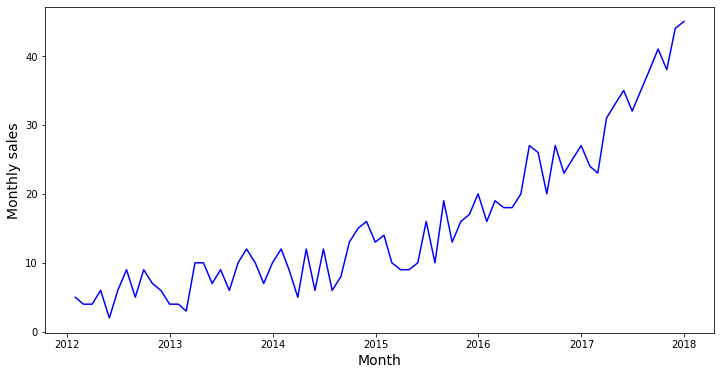

In [ ]:
# Import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Generated monthly sales
years = pd.date_range('2012-01', periods=72, freq='M')
index = pd.DatetimeIndex(years)

np.random.seed(3456)
sales= np.random.randint(-4, high=4, size=72)
bigger = np.array([0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,
                   3,3,3,3,3,3,3,3,7,7,7,7,7,7,7,7,7,7,7,
                   11,11,11,11,11,11,11,11,11,11,18,18,18,
                   18,18,18,18,18,18,26,26,26,26,26,36,36,36,36,36])
final_series = sales+bigger+6
data = pd.Series(final_series, index=index)
fig = plt.figure(figsize=(12,6))
plt.plot(data, color='blue')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Monthly sales', fontsize=14)
plt.show()

We can use numpy's `log()` function to get the log transform of the time series and compare the output with the original time series.

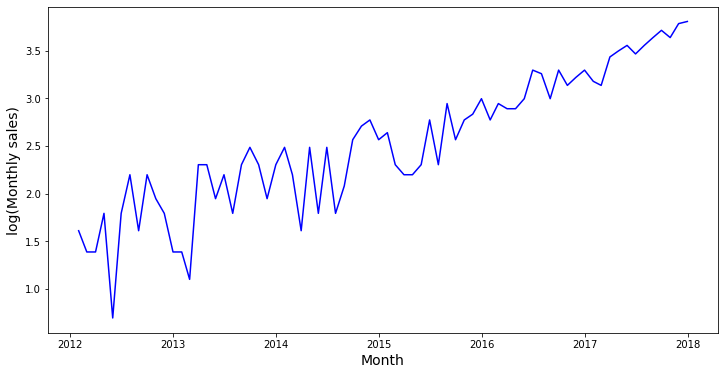

In [ ]:
data = pd.Series(np.log(final_series), index=index)
fig = plt.figure(figsize=(12,6))
plt.plot(data, color='blue')
plt.xlabel('Month', fontsize=14)
plt.ylabel('log(Monthly sales)', fontsize=14)
plt.show()

You can notice here that this series is not stationary (yet), but taking the log did make the trend more linear, which might be a first step in the right direction. The issue is however that there seems to be more heteroscedasticity in the model now. Let's look at what happens if you take the square root of this series.

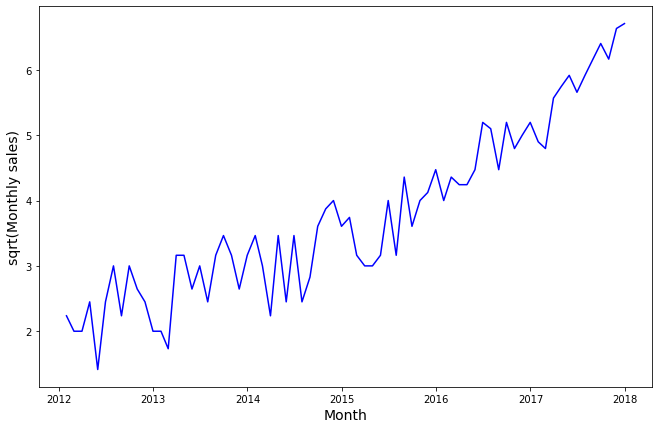

In [ ]:
data = pd.Series(np.sqrt(final_series), index=index)
fig = plt.figure(figsize=(11,7))
plt.plot(data, color='blue')
plt.xlabel('Month', fontsize=14)
plt.ylabel('sqrt(Monthly sales)', fontsize=14)
plt.show()

This looks a little better, but still not ideal in this case. You'll notice that for some data the log or square root transform is really the way to go. For now, let's move on to the next option: subtracting the rolling mean.

### Subtracting the rolling mean

#### The rolling mean

From previously, you know that you can look at the rolling mean to visually check if the mean changes over time.

The rolling mean can actually serve another purpose as well. You can calculate the rolling mean and subtract it from the time series to make sure your time series is stationary. The code to do this can be found below:

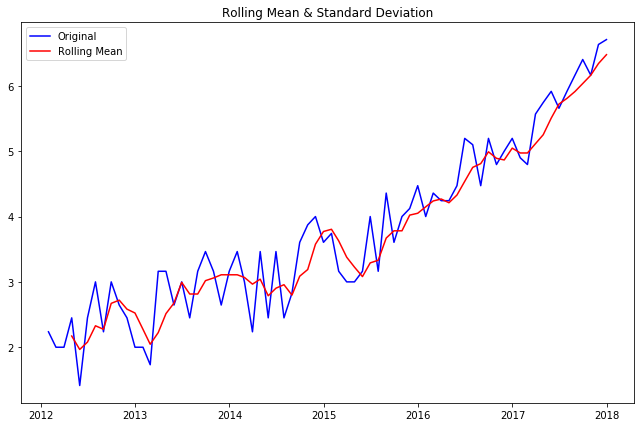

In [ ]:
roll_mean = data.rolling(window=4).mean()
fig = plt.figure(figsize=(11,7))
plt.plot(data, color='blue',label='Original')
plt.plot(roll_mean, color='red', label='Rolling Mean')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

The red line shows the rolling mean. Let's subtract this from the original series. Note that since we are taking the average of the last four values, the rolling mean is not defined for the first three values.

In [ ]:
# Subtract the moving average from the original data
data_minus_roll_mean = data - roll_mean
data_minus_roll_mean.head(15)

2012-01-31         NaN
2012-02-29         NaN
2012-03-31         NaN
2012-04-30    0.278100
2012-05-31   -0.551712
2012-06-30    0.371191
2012-07-31    0.671702
2012-08-31   -0.038875
2012-09-30    0.328611
2012-10-31   -0.074704
2012-11-30   -0.133338
2012-12-31   -0.523810
2013-01-31   -0.273810
2013-02-28   -0.313334
2013-03-31    0.938696
Freq: M, dtype: float64

In [ ]:
# Drop the missing values from time series calculated above
data_minus_roll_mean.dropna(inplace=True)

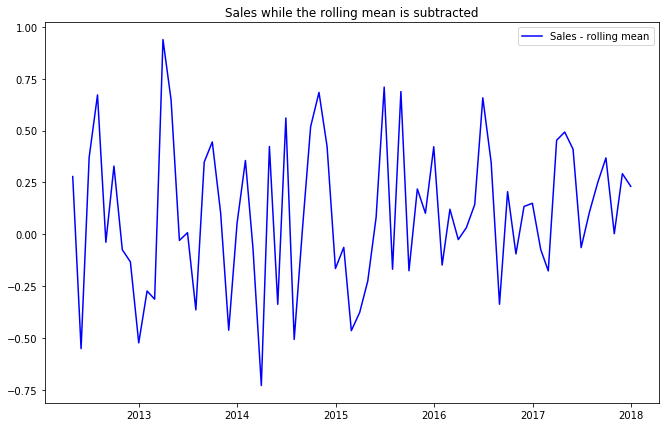

In [ ]:
fig = plt.figure(figsize=(11,7))
plt.plot(data_minus_roll_mean, color='blue',label='Sales - rolling mean')
plt.legend(loc='best')
plt.title('Sales while the rolling mean is subtracted')
plt.show(block=False)

This seems to be more or less stationary! Note that you can change the window length, which will affect what your eventual time series will look like. You'll experiment with this in the lab!

#### The weighted rolling mean

A drawback of the rolling mean approach is that the window has to be strictly defined. In this case, we can take yearly averages but in complex situations like forecasting a stock price, it may be difficult to come up with an exact number. So we take a "weighted rolling mean" (or weighted moving average, WMA for short) where more recent values are given a higher weight. There are several techniques for assigning weights. A popular one is **Exponentially Weighted Moving Average** where weights are assigned to all the previous values with an exponential decay factor. This can be implemented in Pandas with `.ewm()` method. Details can be found [here](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.ewm.html).

Note that here the parameter `halflife` is used to define the amount of exponential decay. This is just an assumption here and would depend largely on the business domain. Other parameters like span and center of mass can also be used to define decay. These definitions are discussed in the link shared above.

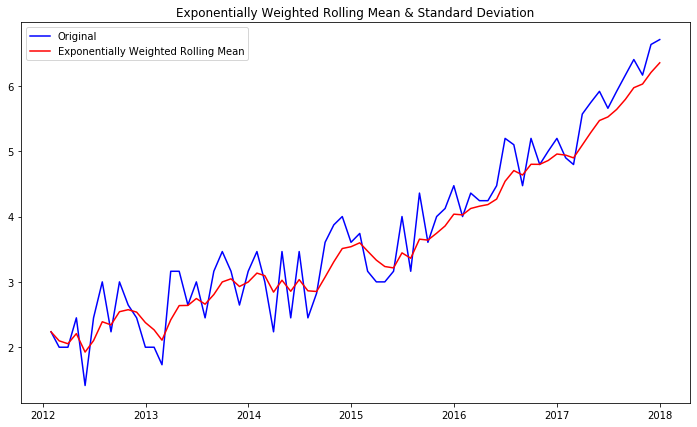

In [ ]:
# Use Pandas ewm() to calculate Exponential Weighted Moving Average
exp_roll_mean = data.ewm(halflife=2).mean()

# Plot the original data with exp weighted average
fig = plt.figure(figsize=(12,7))
orig = plt.plot(data, color='blue',label='Original')
mean = plt.plot(exp_roll_mean, color='red', label='Exponentially Weighted Rolling Mean')
plt.legend(loc='best')
plt.title('Exponentially Weighted Rolling Mean & Standard Deviation')
plt.show(block=False)

In [ ]:
# Subtract the moving average from the original data
data_minus_exp_roll_mean = data - exp_roll_mean
data_minus_exp_roll_mean.head(15)

2012-01-31    0.000000
2012-02-29   -0.097783
2012-03-31   -0.053479
2012-04-30    0.241359
2012-05-31   -0.511451
2012-06-30    0.348483
2012-07-31    0.610154
2012-08-31   -0.105735
2012-09-30    0.456502
2012-10-31    0.071338
2012-11-30   -0.087508
2012-12-31   -0.377218
2013-01-31   -0.265499
2013-02-28   -0.375975
2013-03-31    0.743754
Freq: M, dtype: float64

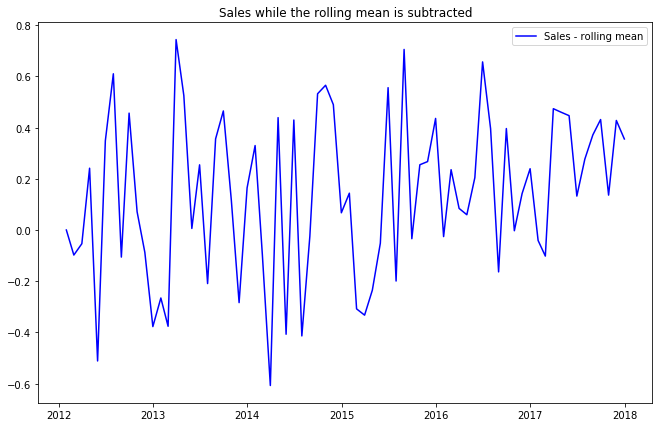

In [ ]:
fig = plt.figure(figsize=(11,7))
plt.plot(data_minus_exp_roll_mean, color='blue',label='Sales - rolling mean')
plt.legend(loc='best')
plt.title('Sales while the rolling mean is subtracted')
plt.show(block=False)

For our sales data, subtracting the weighted mean does not seem to have a better effect than simply subtracting the rolling mean. Still, this might be better in some cases. 

### Differencing

One of the most common methods of dealing with both trend and seasonality is differencing. In this technique, we take the difference of an observation at a particular time instant with that at the previous instant (i.e. a so-called 1-period "lag"). 

This mostly works pretty well in improving stationarity. First-order differencing can be done in Pandas using the `.diff()` method with `periods=1` (denoting a 1-period lag). Details on `.diff()` can be found [here](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.diff.html).

In [ ]:
data_diff = data.diff(periods=1)
data_diff.head(10)

2012-01-31         NaN
2012-02-29   -0.236068
2012-03-31    0.000000
2012-04-30    0.449490
2012-05-31   -1.035276
2012-06-30    1.035276
2012-07-31    0.550510
2012-08-31   -0.763932
2012-09-30    0.763932
2012-10-31   -0.354249
Freq: M, dtype: float64

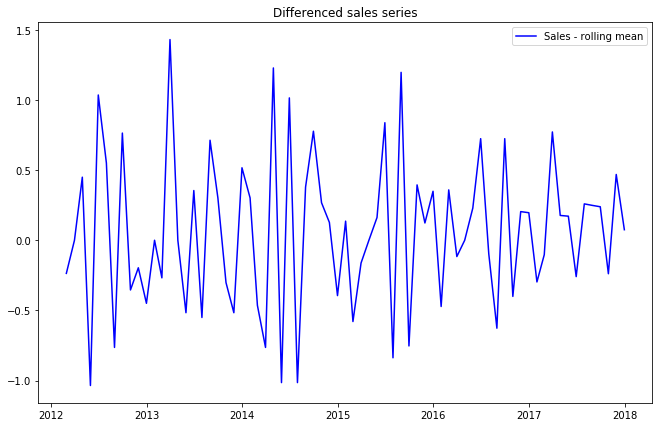

In [ ]:
fig = plt.figure(figsize=(11,7))
plt.plot(data_diff, color='blue',label='Sales - rolling mean')
plt.legend(loc='best')
plt.title('Differenced sales series')
plt.show(block=False)

This seems to work pretty well if you want to make the series stationary!

Differencing is a very popular tool to remove seasonal trends from time series. Let's circle back to the temperatures time series we have been working with in this section.

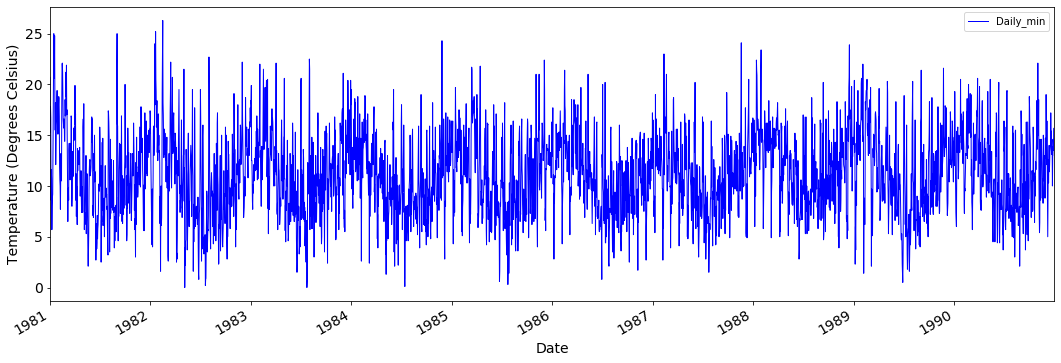

In [ ]:
data = pd.read_csv('data/removing_trends/min_temp.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

data.plot(figsize=(18,6), color='blue', linewidth=1, fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Temperature (Degrees Celsius)', fontsize=14);

Here, we differenced our temperature data by taking differences of exactly one year, which removes the cyclical seasonality from the time series data! Pretty magical!

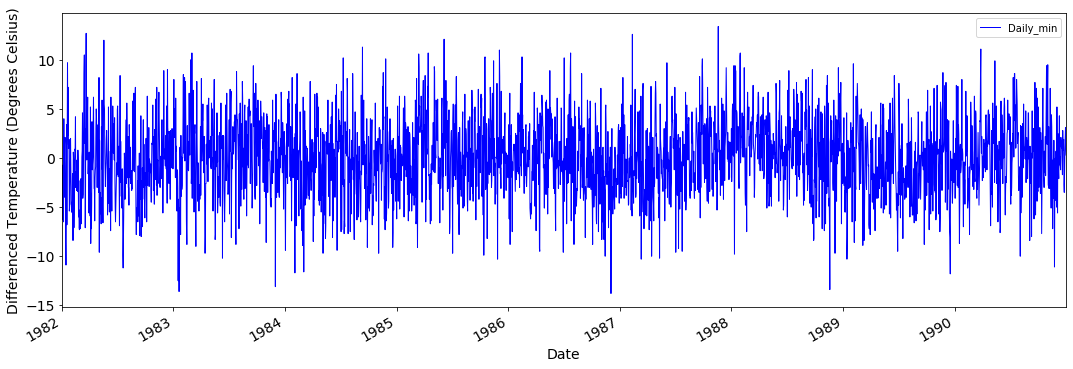

In [ ]:
data_diff = data.diff(periods=365)
data_diff.dropna(inplace=True)
data_diff.plot(figsize=(18,6), color='blue', linewidth=1, fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Differenced Temperature (Degrees Celsius)', fontsize=14);

---

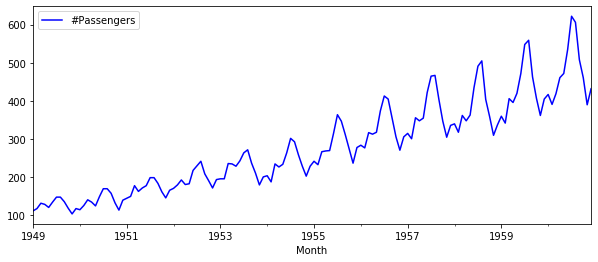

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

# Import the check_stationarity function from previous lab
def stationarity_check(TS):
    
    # Import adfuller
    from statsmodels.tsa.stattools import adfuller
    
    # Calculate rolling statistics
    roll_mean = TS.rolling(window=8, center=False).mean()
    roll_std = TS.rolling(window=8, center=False).std()
    
    # Perform the Dickey Fuller test
    dftest = adfuller(TS['#Passengers']) 
    
    # Plot rolling statistics:
    fig = plt.figure(figsize=(12,6))
    orig = plt.plot(TS, color='blue',label='Original')
    mean = plt.plot(roll_mean, color='red', label='Rolling Mean')
    std = plt.plot(roll_std, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    # Print Dickey-Fuller test results
    print('Results of Dickey-Fuller Test: \n')

    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', 
                                             '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    
    return None

# Import 'data/time_series_decomposition/passengers.csv' dataset
data = pd.read_csv('data/time_series_decomposition/passengers.csv')

# Change the data type of the 'Month' column
data['Month'] = pd.to_datetime(data['Month'])

# Set the 'Month' column as the index
ts = data.set_index('Month')

# Plot the time series
ts.plot(figsize=(10,4), color='blue');

## Time Series Decomposition

Time series decomposition is a mathematical procedure that transforms a time series into multiple different time series. The original time series is often split into three component series:

- **Seasonal**: Patterns that repeat within a fixed period. For example, a website might receive more visits during weekends; this would produce data with a seasonality of 7 days.

- **Trend**: The underlying trend of the metrics. A website increasing in popularity should show a general trend that goes up.

- **Random**: Also called "noise", "irregular", or "remainder", this is the residual of the original time series after the seasonal and trend series are removed.


## Additive or Multiplicative Decomposition?

To achieve successful decomposition, it is important to choose between the additive and multiplicative models, which requires analyzing the series. For example, does the magnitude of the seasonality increase when the time series increases?

![](assets/time_series_decomposition/new_seasonality.png)


Fortunately, `statsmodels` provides the convenient `seasonal_decompose()` function to perform such decomposition out of the box. Details of this function are available [here](http://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.seasonal_decompose.html). 

In the following cell, we will: 

- Import `seasonal_decompose()` from `statsmodels.tsa.seasonal`  
- Apply `seasonal_decompose()` to the log transformed time series   
- Plot the trend, seasonality, and residuals

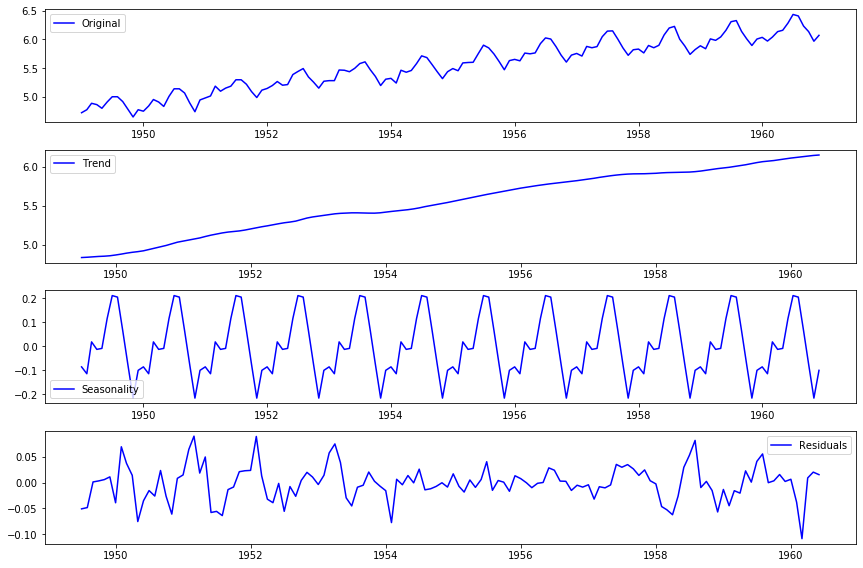

In [ ]:
# Import and apply seasonal_decompose()
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(np.log(ts))

# Gather the trend, seasonality, and residuals 
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot gathered statistics
plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(np.log(ts), label='Original', color='blue')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Trend', color='blue')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal,label='Seasonality', color='blue')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuals', color='blue')
plt.legend(loc='best')
plt.tight_layout()

Here we can see that the trend and seasonality are separated from data and we can model the residuals.

Using time-series decomposition makes it easier to quickly identify a changing mean or variation in the data. The plot above clearly shows the upward trend of our data, along with its yearly seasonality. These can be used to understand the structure of our time series. The intuition behind time series decomposition is important, as many forecasting methods are built upon this concept of structured decomposition to produce forecasts.

Lets check stationarity of residuals using our `check_stationarity()` function.

> NOTE: We first drop the missing values.

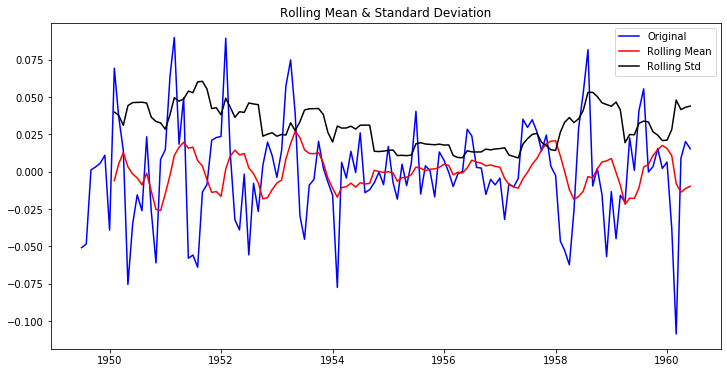

Results of Dickey-Fuller Test: 

Test Statistic                -6.332387e+00
p-value                        2.885059e-08
#Lags Used                     9.000000e+00
Number of Observations Used    1.220000e+02
Critical Value (1%)           -3.485122e+00
Critical Value (5%)           -2.885538e+00
Critical Value (10%)          -2.579569e+00
dtype: float64


In [ ]:
# Drop missing values from residuals 
ts_log_decompose = residual
ts_log_decompose.dropna(inplace=True)

# Check stationarity
stationarity_check(ts_log_decompose)

The Dickey-Fuller test statistic is significant and very well below a (strict) 0.01 mark. So it seems reasonable to assume this time series is stationary.

## Additional resources

We strongly recommend you to read this blogpost on [decomposing time series](https://machinelearningmastery.com/decompose-time-series-data-trend-seasonality/)!

---

## Detrending the Air passenger data 

In this lab you will work with the air passenger dataset available in `'data/removing_trends_lab/passengers.csv'`. First, run the following cell to import the necessary libraries.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

- Import the `'data/removing_trends_lab/passengers.csv'` dataset 
- Change the data type of the `'Month'` column to a proper date format 
- Set the `'Month'` column as the index of the DataFrame 
- Print the first five rows of the dataset

In [ ]:
# Import 'data/removing_trends_lab/passengers.csv' dataset
data = None

# Change the data type of the 'Month' column
data['Month'] = None

# Set the 'Month' column as the index
ts = None

# Print the first five rows


Plot this time series.

In [ ]:
# Plot the time series


## Create a stationarity check

Your next task is to use the code from previous labs to create a function `stationarity_check()` that takes in a time series and performs stationarity checks including rolling statistics and the Dickey-Fuller test. 

We want the output of the function to: 

- Plot the original time series along with the rolling mean and rolling standard deviation (use a window of 8) in one plot 
- Output the results of the Dickey-Fuller test

In [ ]:
# Create a function to check for the stationarity of a given time series using rolling stats and DF test
# Collect and package the code from previous labs


Use your newly created function on the `ts` timeseries.

In [ ]:
# Code here

## Perform a log and square root transform

Plot a log transform of the original time series (`ts`).

In [ ]:
# Plot a log transform


Plot a square root  transform of the original time series (`ts`).

In [ ]:
# Plot a square root transform


Going forward, let's keep working with the log transformed data before subtracting rolling mean, differencing, etc.

## Subtracting the rolling mean

Create a rolling mean using your log transformed time series, with a time window of 7. Plot the log-transformed time series and the rolling mean together.

In [ ]:
# your code here
roll_mean = None
fig = plt.figure(figsize=(11,7)) 


Now, subtract this rolling mean from the log transformed time series, and look at the 10 first elements of the result.

In [ ]:
# Subtract the moving average from the log transformed data
data_minus_roll_mean = None

# Print the first 10 rows


Drop the missing values from this time series.

In [ ]:
# Drop the missing values


Plot this time series now.

In [ ]:
# Plot the result


Finally, use your function `check_stationarity()` to see if this series is stationary!

In [ ]:
# Your code here

### Based on the visuals and on the Dickey-Fuller test, what do you conclude?

In [ ]:
# Your conclusion here

## Subtracting the weighted rolling mean

Repeat all the above steps to calculate the exponential *weighted* rolling mean with a halflife of 4. Start from the log-transformed data again. Compare the Dickey-Fuller test results. What do you conclude?

In [ ]:
# Calculate Weighted Moving Average of log transformed data
exp_roll_mean = None

# Plot the original data with exp weighted average


- Subtract this exponential weighted rolling mean from the log transformed data  
- Print the resulting time series

In [ ]:
# Subtract the exponential weighted rolling mean from the original data 
data_minus_exp_roll_mean = None

# Plot the time series


Check for stationarity of `data_minus_exp_roll_mean` using your function.

In [ ]:
# Do a stationarity check

### Based on the visuals and on the Dickey-Fuller test, what do you conclude?

In [ ]:
# Your conclusion here

## Differencing

Using exponentially weighted moving averages, we seem to have removed the upward trend, but not the seasonality issue. Now use differencing to remove seasonality. Make sure you use the right amount of `periods`. Start from the log-transformed, exponentially weighted rolling mean-subtracted series.

After you differenced the series, drop the missing values, plot the resulting time series, and then run the `stationarity check()` again.

In [ ]:
# Difference your data
data_diff = None

# Drop the missing values


# Check out the first few rows
data_diff.head(15)

Plot the resulting differenced time series.

In [ ]:
# Plot your differenced time series


In [ ]:
# Perform the stationarity check

### Your conclusion

In [ ]:
# Your conclusion here

---

## Importing the data

Let's look at some new data. In this lab, we'll work with a time series in Python by using the popular [Air Passengers dataset](https://www.analyticsvidhya.com/wp-content/uploads/2016/02/AirPassengers.csv).

Start by running the cell below to import the necessary libraries.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

The dataset is stored in `'data/testing_for_trends_lab/passengers.csv'`. Import it and view the first five rows.

In [ ]:
# Import 'data/testing_for_trends_lab/passengers.csv'
data = None

# View the first five rows


Change the `'Month'` column over to a `datetime` type and make sure it is set as the index of the DataFrame.

In [ ]:
# Change the type of 'Month' to datetime


# Set 'Month' as the index


In [ ]:
# Check the index


Now that we have successfully created a time series, we can use the `.plot()` method in pandas to visually inspect this time series.

In [ ]:
# Plot the time series data 


Wec can see that that there is an overall increasing trend in the data along with some seasonal variations. However, it might not always be possible to make such visual inferences. Let's reconfirm this here using both **rolling statistics** and the **Dickey-Fuller test**.

## Rolling Statistics 

Use the `.rolling()` method to find the rolling mean and rolling std with a window of 12 months. Plot the original curve along with the rolling mean and standard error.

In [ ]:
# Determine rolling statistics


In [ ]:
# Plot rolling statistics


Though the variation in standard deviation is small, the mean is increasing with time and thus, this is not a stationary series.

## Dickey-Fuller Test 

Use the Dickey-Fuller test to verify your visual result.

In [ ]:
from statsmodels.tsa.stattools import adfuller
